<a href="https://colab.research.google.com/github/DANGERdanya0/Portfolio/blob/main/%D0%92%D0%B5%D0%B4%D0%BE%D0%BC%D0%BE%D1%81%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl -q
!pip install tabula-py pypdf2 pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 17.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tabula
import re

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1ИСиП-923 з.pdf to 1ИСиП-923 з.pdf
Saving 1ИСиП-1023 з.pdf to 1ИСиП-1023 з.pdf
Saving 1ИИС-1523 инф зачет.pdf to 1ИИС-1523 инф зачет.pdf


Извлекает данные из PDF-ведомости. Возвращает DataFrame с колонками: student_name, grade_text, teacher, date


In [ ]:
def extract_grades_from_pdf(pdf_file):
    # Читаем все таблицы из PDF
    tables = tabula.read_pdf(pdf_file, pages='all', multiple_tables=True)

    all_data = []

    for table in tables:
        # Ищем строки, содержащие оценки
        for idx, row in table.iterrows():
            row_text = ' '.join([str(val) for val in row.values if pd.notna(val)])

            # Поиск оценки в формате "5 (отлично)", "4 (хорошо)", "3 (удовлетворительно)", "2 (неудовлетворительно)"
            grade_match = re.search(r'(\d+)\s*\(([^)]+)\)', row_text)
            if grade_match:
                grade_num = grade_match.group(1)
                grade_word = grade_match.group(2)

                # Извлекаем ФИО студента (первые 2-3 слова в строке)
                name_match = re.match(r'^([А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+)', row_text)
                if name_match:
                    student_name = name_match.group(1)
                else:
                    student_name = row.iloc[1] if len(row) > 1 else f"Студент_{idx}"

                # Поиск преподавателя (Нинкин или Нижник)
                teacher_match = re.search(r'(Нинкин|Нижник)\s+[А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+', row_text)
                if teacher_match:
                    teacher = teacher_match.group(0)
                else:
                    teacher = "Нинкин Кирилл Юрьевич"  # по умолчанию

                # Поиск даты
                date_match = re.search(r'(\d{2})\.(\d{2})\.(\d{4})', row_text)
                date = date_match.group(0) if date_match else "21.12.2023"

                all_data.append({
                    'student_name': student_name,
                    'grade_num': int(grade_num),
                    'grade_text': grade_word,
                    'teacher': teacher,
                    'date': date
                })

            # Обработка случая "Не явился"
            elif 'Не явился' in row_text:
                name_match = re.match(r'^([А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+)', row_text)
                student_name = name_match.group(1) if name_match else f"Студент_{idx}"

                teacher_match = re.search(r'(Нинкин|Нижник)\s+[А-ЯЁа-яё]+\s+[А-ЯЁа-яё]+', row_text)
                teacher = teacher_match.group(0) if teacher_match else "Нинкин Кирилл Юрьевич"

                date_match = re.search(r'(\d{2})\.(\d{2})\.(\d{4})', row_text)
                date = date_match.group(0) if date_match else "21.12.2023"

                all_data.append({
                    'student_name': student_name,
                    'grade_num': 0,  # 0 = н/а
                    'grade_text': 'не явился',
                    'teacher': teacher,
                    'date': date
                })

    return pd.DataFrame(all_data)

In [ ]:
all_dfs = []

for filename in uploaded.keys():
    if filename.endswith('.pdf'):
        print(f"Обработка файла: {filename}")
        df = extract_grades_from_pdf(filename)
        all_dfs.append(df)
        print(f"  Найдено записей: {len(df)}")

Обработка файла: 1ИСиП-923 з.pdf


Apr 02, 2026 9:58:19 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>



  Найдено записей: 22
Обработка файла: 1ИСиП-1023 з.pdf


Apr 02, 2026 9:58:25 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>



  Найдено записей: 28
Обработка файла: 1ИИС-1523 инф зачет.pdf


Apr 02, 2026 9:58:32 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>



  Найдено записей: 21


ФУНКЦИЯ ДЛЯ РАСЧЁТА ПОКАЗАТЕЛЕЙ

In [ ]:
def calculate_metrics(df, title="Результаты"):
    """Рассчитывает все показатели для переданного DataFrame"""

    total = len(df)

    count_5 = (df['grade_num'] == 5).sum()
    count_4 = (df['grade_num'] == 4).sum()
    count_3 = (df['grade_num'] == 3).sum()
    count_2 = (df['grade_num'] == 2).sum()
    count_na = (df['grade_num'] == 0).sum()

    absolute_success = (count_5 + count_4 + count_3) * 100 / total if total > 0 else 0
    quality_success = (count_5 + count_4) * 100 / total if total > 0 else 0
    sou = (count_5 * 100 + count_4 * 64 + count_3 * 36 + count_2 * 16 + count_na * 7) / total if total > 0 else 0

    return {
        'title': title,
        'total': total,
        'count_5': count_5,
        'count_4': count_4,
        'count_3': count_3,
        'count_2': count_2,
        'count_na': count_na,
        'absolute_success': absolute_success,
        'quality_success': quality_success,
        'sou': sou
    }

Статистический анализ (среднее, медиана, мода)

In [ ]:
# ==================== БЛОК 2: СТАТИСТИЧЕСКИЙ АНАЛИЗ ====================
print("\n" + "="*60)
print("2️⃣ СТАТИСТИЧЕСКИЙ АНАЛИЗ (СРЕДНЕЕ, МЕДИАНА, МОДА)")
print("="*60)

# Используем уже созданный df_cluster из Блока 1
# Если Блок 1 не запускали, создаём df_cluster заново
if 'df_cluster' not in locals():
    def extract_group_name(filename):
        if '923' in filename:
            return 'ИСиП-923'
        elif '1023' in filename:
            return 'ИСиП-1023'
        elif '1523' in filename:
            return 'ИИС-1523'
        else:
            return 'Другая группа'

    for i, df in enumerate(all_data_frames):
        group_name = extract_group_name(all_metrics[i]['title'])
        df['group'] = group_name

    df_cluster = pd.concat(all_data_frames, ignore_index=True)
    df_cluster = df_cluster.drop_duplicates(subset=['student_name'])

# Общая статистика по всем студентам
print("\n📊 ОБЩАЯ СТАТИСТИКА (все студенты):")
print(f"  Средний балл: {df_cluster['grade_num'].mean():.2f}")
print(f"  Медиана: {df_cluster['grade_num'].median():.2f}")
print(f"  Мода: {df_cluster['grade_num'].mode()[0]}")
print(f"  Стандартное отклонение: {df_cluster['grade_num'].std():.2f}")
print(f"  Минимальный балл: {df_cluster['grade_num'].min()}")
print(f"  Максимальный балл: {df_cluster['grade_num'].max()}")
print(f"  Дисперсия: {df_cluster['grade_num'].var():.2f}")

# Статистика по группам
print("\n📊 СТАТИСТИКА ПО ГРУППАМ:")
group_stats = df_cluster.groupby('group')['grade_num'].agg([
    ('Средний балл', 'mean'),
    ('Медиана', 'median'),
    ('Мода', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    ('Стд отклонение', 'std'),
    ('Мин', 'min'),
    ('Макс', 'max'),
    ('Кол-во', 'count')
]).round(2)

print(group_stats)

# Визуализация: ящик с усами (Box plot) по группам
plt.figure(figsize=(10, 6))
groups = df_cluster['group'].unique()
box_data = [df_cluster[df_cluster['group'] == g]['grade_num'].values for g in groups]

bp = plt.boxplot(box_data, labels=groups, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)

plt.title('Распределение оценок по группам (Box plot)', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Оценка')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Визуализация: сравнение средних баллов
plt.figure(figsize=(8, 5))
group_means = df_cluster.groupby('group')['grade_num'].mean().sort_values()
colors_mean = ['#2ecc71' if x >= 4 else '#f39c12' if x >= 3 else '#e74c3c' for x in group_means.values]
plt.barh(group_means.index, group_means.values, color=colors_mean, edgecolor='black')
plt.xlabel('Средний балл')
plt.title('Сравнение среднего балла по группам', fontsize=14)
plt.xlim(0, 5)

# Добавляем значения
for i, v in enumerate(group_means.values):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

ФУНКЦИЯ ДЛЯ ПОСТРОЕНИЯ ГРАФИКОВ

In [ ]:
def plot_all_charts(metrics):
    """Строит круговую и столбчатую диаграммы для переданных метрик"""
    title = metrics['title']

    labels = ['Отлично (5)', 'Хорошо (4)', 'Удовлетворительно (3)',
              'Неудовлетворительно (2)', 'Не явились']

    counts = [metrics['count_5'], metrics['count_4'], metrics['count_3'],
              metrics['count_2'], metrics['count_na']]

    colors = ['#2ec7f1', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']

    # Круговая диаграмма (только ненулевые значения)
    non_zero = [(l, c, col) for l, c, col in zip(labels, counts, colors) if c > 0]

    if non_zero:
        pie_labels, pie_counts, pie_colors = zip(*non_zero)
        plt.figure(figsize=(7, 7))
        plt.pie(pie_counts, labels=pie_labels, colors=pie_colors,
                autopct='%1.1f%%', shadow=True, startangle=90)
        plt.title(f'Распределение оценок\n{title}', fontsize=12)
        plt.axis('equal')
        plt.show()

    # Столбчатая диаграмма
    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.2)
    plt.title(f'Количество студентов по оценкам\n{title}', fontsize=14)
    plt.xlabel('Оценка')
    plt.ylabel('Количество студентов')
    plt.grid(axis='y', alpha=0.3)

    for i, v in enumerate(counts):
        plt.text(i, v + 0.3, str(v), ha='center', fontsize=11)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [ ]:
def print_metrics(metrics):
    """Выводит результаты расчётов в консоль"""

    print("\n" + "="*60)
    print(f"📊 {metrics['title']}")
    print("="*60)
    print(f"\n👥 Общее количество учащихся: {metrics['total']}")
    print(f"⭐ Отлично (5): {metrics['count_5']}")
    print(f"✅ Хорошо (4): {metrics['count_4']}")
    print(f"📗 Удовлетворительно (3): {metrics['count_3']}")
    print(f"❌ Неудовлетворительно (2): {metrics['count_2']}")
    print(f"🚫 Не явились (н/а): {metrics['count_na']}")
    print(f"\n📈 Процент успеваемости: {metrics['absolute_success']:.2f}%")
    print(f"🎯 Процент качества знаний: {metrics['quality_success']:.2f}%")
    print(f"📚 Степень обученности (СОУ): {metrics['sou']:.2f}")


🔍 АНАЛИЗ ВЕДОМОСТЕЙ ПО ИНФОРМАТИКЕ

📄 Обработка файла: 1ИСиП-923 з.pdf


Apr 02, 2026 10:00:36 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>




📊 Файл: 1ИСиП-923 з.pdf

👥 Общее количество учащихся: 22
⭐ Отлично (5): 14
✅ Хорошо (4): 7
📗 Удовлетворительно (3): 0
❌ Неудовлетворительно (2): 0
🚫 Не явились (н/а): 1

📈 Процент успеваемости: 95.45%
🎯 Процент качества знаний: 95.45%
📚 Степень обученности (СОУ): 84.32


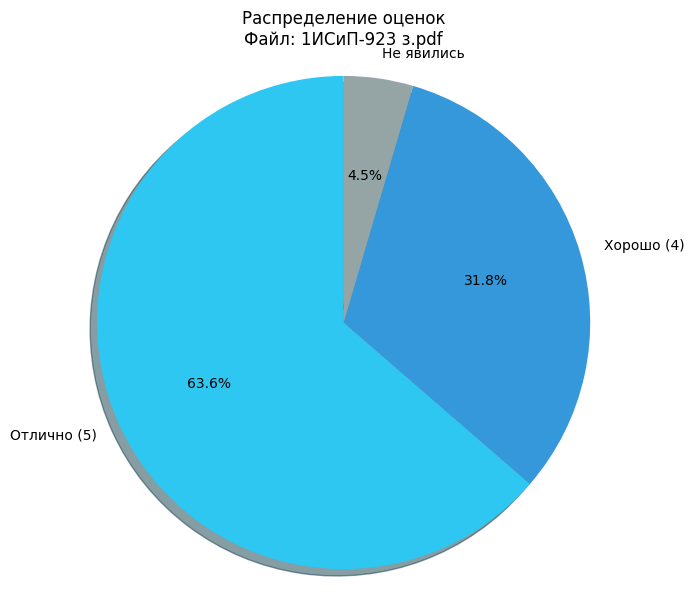

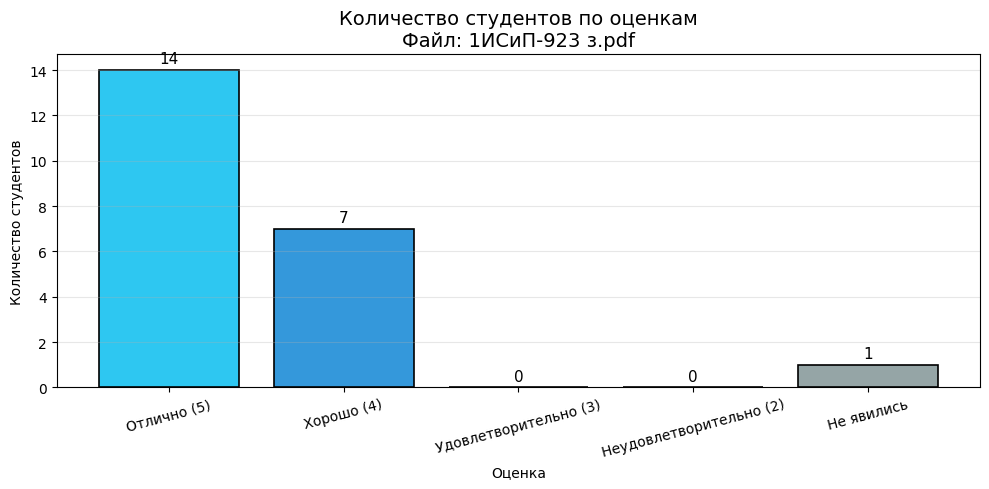


📄 Обработка файла: 1ИСиП-1023 з.pdf


Apr 02, 2026 10:00:43 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>




📊 Файл: 1ИСиП-1023 з.pdf

👥 Общее количество учащихся: 28
⭐ Отлично (5): 25
✅ Хорошо (4): 3
📗 Удовлетворительно (3): 0
❌ Неудовлетворительно (2): 0
🚫 Не явились (н/а): 0

📈 Процент успеваемости: 100.00%
🎯 Процент качества знаний: 100.00%
📚 Степень обученности (СОУ): 96.14


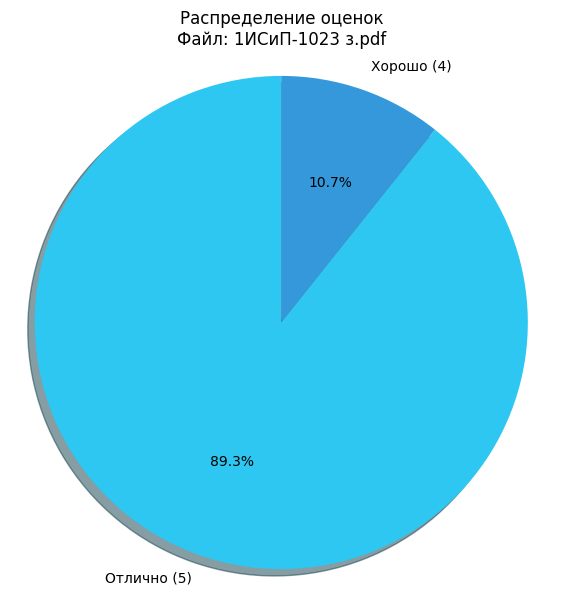

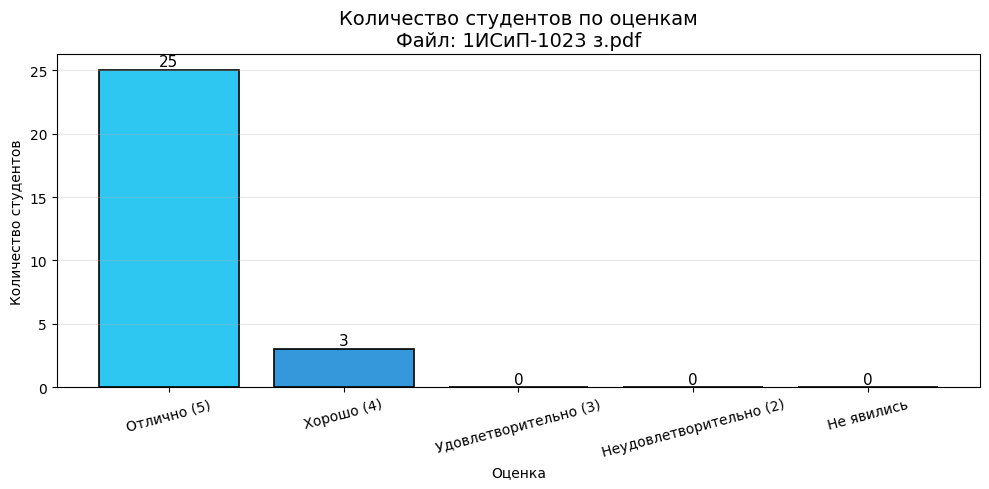


📄 Обработка файла: 1ИИС-1523 инф зачет.pdf


Apr 02, 2026 10:00:49 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>




📊 Файл: 1ИИС-1523 инф зачет.pdf

👥 Общее количество учащихся: 21
⭐ Отлично (5): 10
✅ Хорошо (4): 11
📗 Удовлетворительно (3): 0
❌ Неудовлетворительно (2): 0
🚫 Не явились (н/а): 0

📈 Процент успеваемости: 100.00%
🎯 Процент качества знаний: 100.00%
📚 Степень обученности (СОУ): 81.14


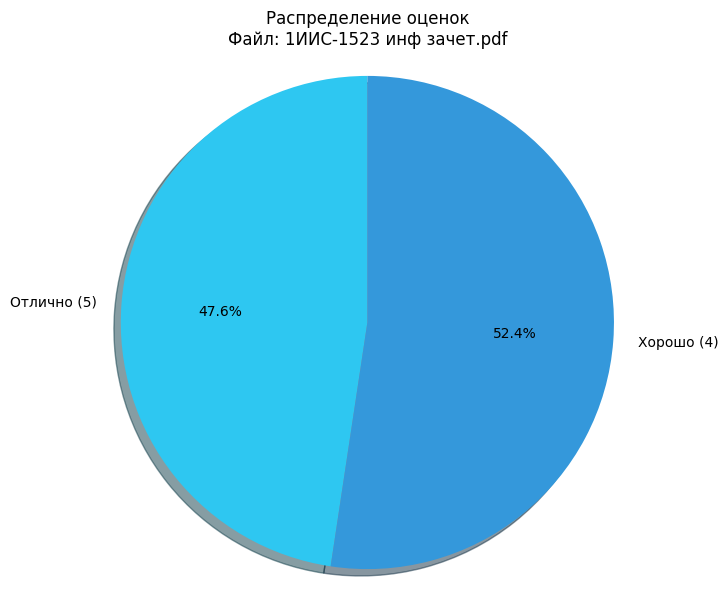

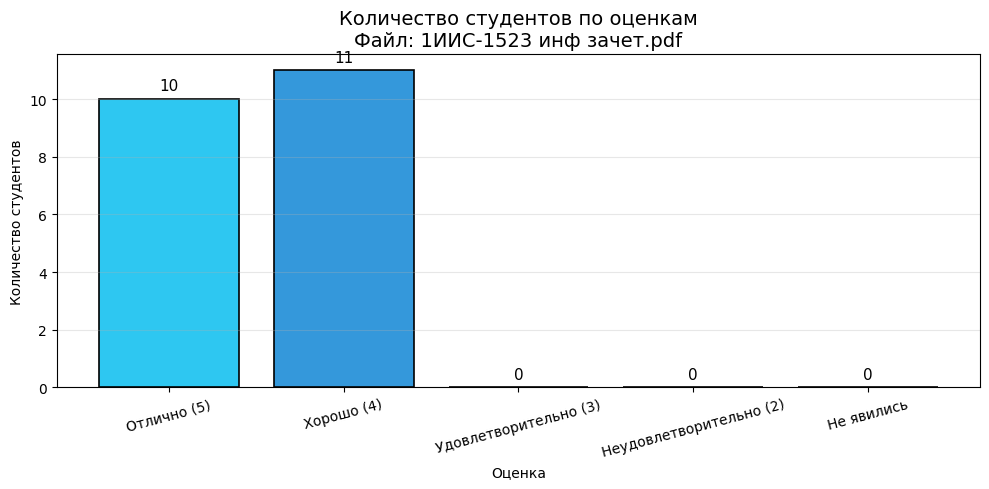

In [ ]:
print("\n" + "="*60)
print("🔍 АНАЛИЗ ВЕДОМОСТЕЙ ПО ИНФОРМАТИКЕ")
print("="*60)

all_metrics = []
all_data_frames = []

for filename in uploaded.keys():
    if filename.endswith('.pdf'):
        print(f"\n📄 Обработка файла: {filename}")

        df = extract_grades_from_pdf(filename)

        # Фильтруем только Нинкин/Нижник
        df = df[df['teacher'].str.contains('Нинкин|Нижник', case=False, na=False)]

        # Приводим оценки к единому формату
        grade_map = {
            'отлично': 5,
            'хорошо': 4,
            'удовлетворительно': 3,
            'неудовлетворительно': 2,
            'не явился': 0
        }
        df['grade_num'] = df['grade_text'].str.lower().map(grade_map).fillna(df['grade_num'])

        if len(df) > 0:
            all_data_frames.append(df)
            metrics = calculate_metrics(df, title=f"Файл: {filename}")
            all_metrics.append(metrics)
            print_metrics(metrics)
            plot_all_charts(metrics)
        else:
            print(f"⚠️ В файле {filename} не найдено данных по преподавателю Нинкин К.Ю.")



🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟

📊 🔴 ОБЩИЙ АНАЛИЗ (все файлы)

👥 Общее количество учащихся: 71
⭐ Отлично (5): 49
✅ Хорошо (4): 21
📗 Удовлетворительно (3): 0
❌ Неудовлетворительно (2): 0
🚫 Не явились (н/а): 1

📈 Процент успеваемости: 98.59%
🎯 Процент качества знаний: 98.59%
📚 Степень обученности (СОУ): 88.04
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


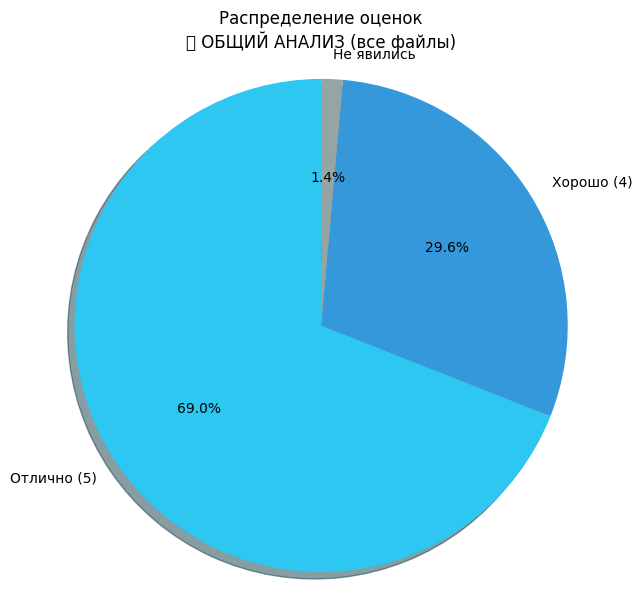

/tmp/ipykernel_5118/364286952.py:37: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


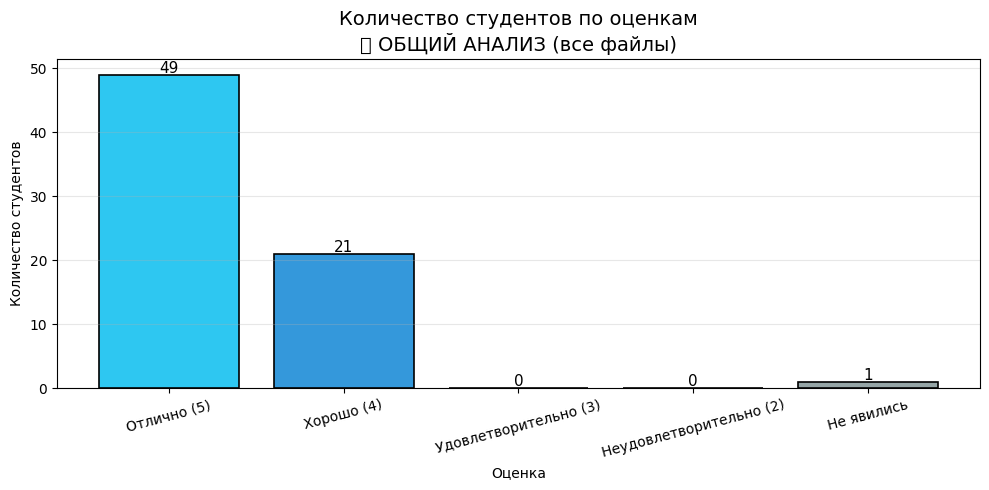


📊 СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ ПО ФАЙЛАМ


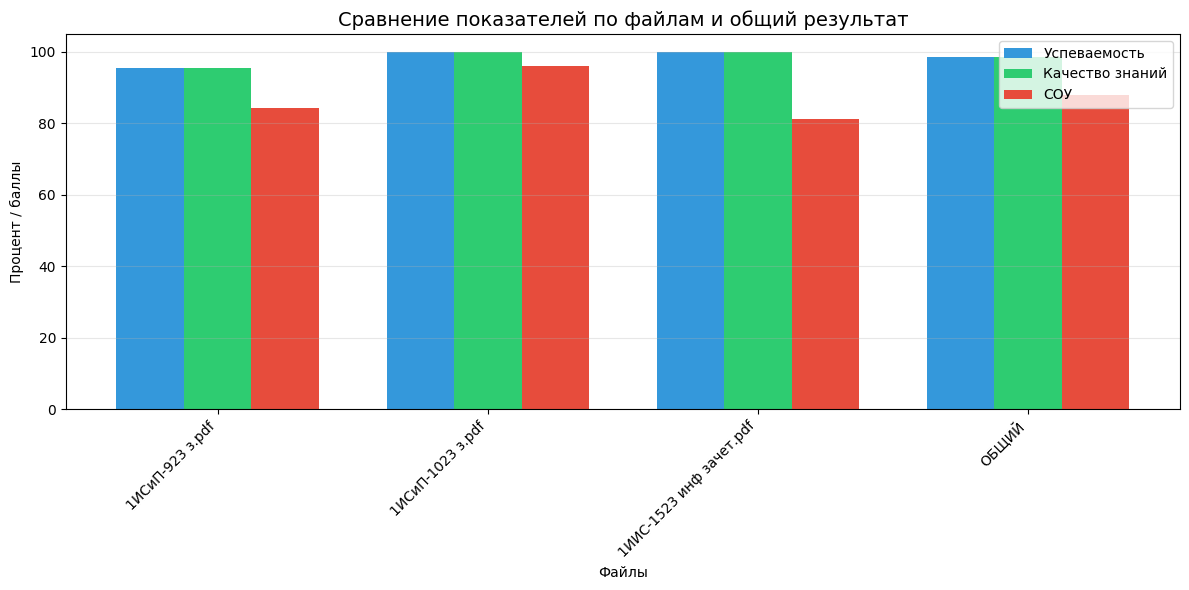

In [ ]:
if all_data_frames:
    df_all = pd.concat(all_data_frames, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=['student_name'])

    total_metrics = calculate_metrics(df_all, title="🔴 ОБЩИЙ АНАЛИЗ (все файлы)")

    print("\n" + "🌟"*30)
    print_metrics(total_metrics)
    print("🌟"*30)
    plot_all_charts(total_metrics)

    # Сравнительная диаграмма
    print("\n📊 СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ ПО ФАЙЛАМ")

    comparison_data = []
    file_names = []

    for m in all_metrics:
        comparison_data.append([m['absolute_success'], m['quality_success'], m['sou']])
        file_names.append(m['title'].replace("Файл: ", "")[:30])

    comparison_data.append([total_metrics['absolute_success'],
                           total_metrics['quality_success'],
                           total_metrics['sou']])
    file_names.append("ОБЩИЙ")

    x = range(len(file_names))
    width = 0.25

    plt.figure(figsize=(12, 6))
    plt.bar([i - width for i in x], [d[0] for d in comparison_data], width,
            label='Успеваемость', color='#3498db')
    plt.bar(x, [d[1] for d in comparison_data], width,
            label='Качество знаний', color='#2ecc71')
    plt.bar([i + width for i in x], [d[2] for d in comparison_data], width,
            label='СОУ', color='#e74c3c')

    plt.xlabel('Файлы')
    plt.ylabel('Процент / баллы')
    plt.title('Сравнение показателей по файлам и общий результат', fontsize=14)
    plt.xticks(x, file_names, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟

📊 🔴 ОБЩИЙ АНАЛИЗ (все файлы)

👥 Общее количество учащихся: 71
⭐ Отлично (5): 49
✅ Хорошо (4): 21
📗 Удовлетворительно (3): 0
❌ Неудовлетворительно (2): 0
🚫 Не явились (н/а): 1

📈 Процент успеваемости: 98.59%
🎯 Процент качества знаний: 98.59%
📚 Степень обученности (СОУ): 88.04
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


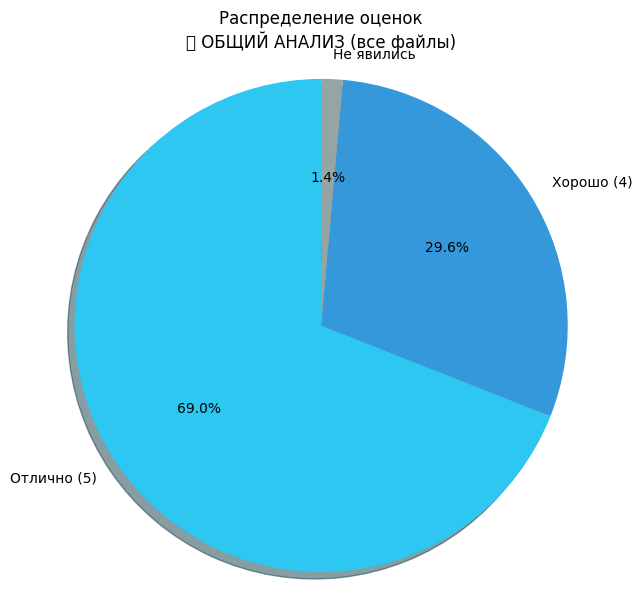

/tmp/ipykernel_5118/364286952.py:37: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


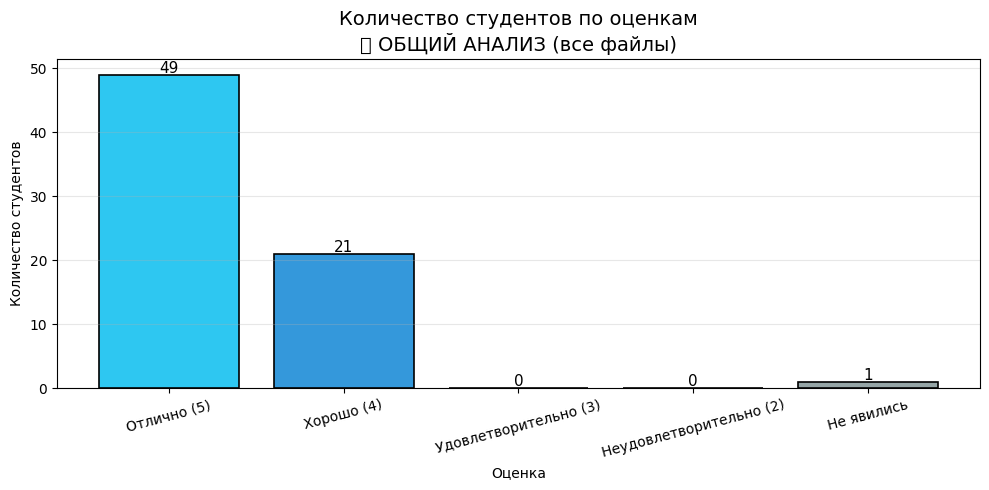


📊 СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ ПО ФАЙЛАМ


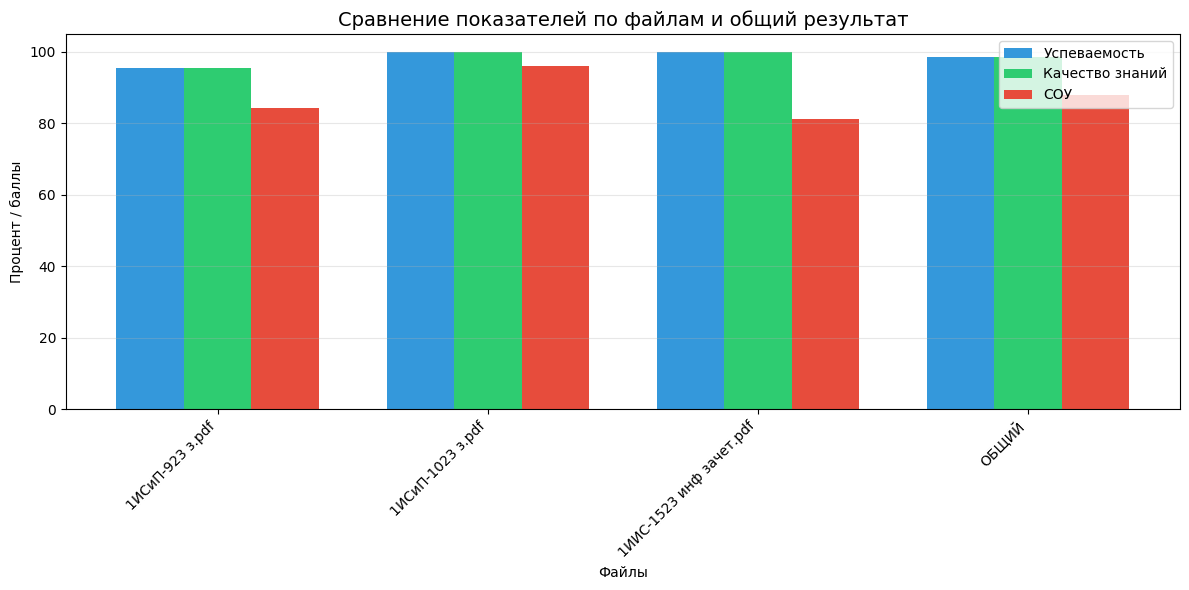


📋 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                   Файл  Всего  5  4  3  2  н/а Успеваемость % Качество %  СОУ
        1ИСиП-923 з.pdf     22 14  7  0  0    1           95.5       95.5 84.3
       1ИСиП-1023 з.pdf     28 25  3  0  0    0          100.0      100.0 96.1
1ИИС-1523 инф зачет.pdf     21 10 11  0  0    0          100.0      100.0 81.1
     === ОБЩИЙ ИТОГ ===     71 49 21  0  0    1           98.6       98.6 88.0


In [ ]:
# ==================== СВОДНАЯ ТАБЛИЦА И СРАВНЕНИЕ ====================
if all_data_frames:
    df_all = pd.concat(all_data_frames, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=['student_name'])

    total_metrics = calculate_metrics(df_all, title="🔴 ОБЩИЙ АНАЛИЗ (все файлы)")

    print("\n" + "🌟"*30)
    print_metrics(total_metrics)
    print("🌟"*30)
    plot_all_charts(total_metrics)

    # Сравнительная диаграмма
    print("\n📊 СРАВНЕНИЕ ПОКАЗАТЕЛЕЙ ПО ФАЙЛАМ")

    comparison_data = []
    file_names = []

    for m in all_metrics:
        comparison_data.append([m['absolute_success'], m['quality_success'], m['sou']])
        file_names.append(m['title'].replace("Файл: ", "")[:30])

    comparison_data.append([total_metrics['absolute_success'],
                           total_metrics['quality_success'],
                           total_metrics['sou']])
    file_names.append("ОБЩИЙ")

    x = range(len(file_names))
    width = 0.25

    plt.figure(figsize=(12, 6))
    plt.bar([i - width for i in x], [d[0] for d in comparison_data], width,
            label='Успеваемость', color='#3498db')
    plt.bar(x, [d[1] for d in comparison_data], width,
            label='Качество знаний', color='#2ecc71')
    plt.bar([i + width for i in x], [d[2] for d in comparison_data], width,
            label='СОУ', color='#e74c3c')

    plt.xlabel('Файлы')
    plt.ylabel('Процент / баллы')
    plt.title('Сравнение показателей по файлам и общий результат', fontsize=14)
    plt.xticks(x, file_names, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Сводная таблица
    print("\n📋 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    summary_df = pd.DataFrame([
        {
            'Файл': m['title'].replace("Файл: ", "")[:40],
            'Всего': m['total'],
            '5': m['count_5'],
            '4': m['count_4'],
            '3': m['count_3'],
            '2': m['count_2'],
            'н/а': m['count_na'],
            'Успеваемость %': f"{m['absolute_success']:.1f}",
            'Качество %': f"{m['quality_success']:.1f}",
            'СОУ': f"{m['sou']:.1f}"
        } for m in all_metrics
    ])

    summary_df.loc[len(summary_df)] = {
        'Файл': '=== ОБЩИЙ ИТОГ ===',
        'Всего': total_metrics['total'],
        '5': total_metrics['count_5'],
        '4': total_metrics['count_4'],
        '3': total_metrics['count_3'],
        '2': total_metrics['count_2'],
        'н/а': total_metrics['count_na'],
        'Успеваемость %': f"{total_metrics['absolute_success']:.1f}",
        'Качество %': f"{total_metrics['quality_success']:.1f}",
        'СОУ': f"{total_metrics['sou']:.1f}"
    }

    print(summary_df.to_string(index=False))

else:
    print("\n❌ Нет данных для анализа")

In [ ]:
# ==================== БЛОК 1: РАСПРЕДЕЛЕНИЕ ПО УРОВНЯМ (КЛАСТЕРИЗАЦИЯ) ====================
print("\n" + "="*60)
print("1️⃣ РАСПРЕДЕЛЕНИЕ СТУДЕНТОВ ПО УРОВНЯМ (КЛАСТЕРИЗАЦИЯ)")
print("="*60)

# Функция для извлечения номера группы из названия файла
def extract_group_name(filename):
    if '923' in filename:
        return 'ИСиП-923'
    elif '1023' in filename:
        return 'ИСиП-1023'
    elif '1523' in filename:
        return 'ИИС-1523'
    else:
        return 'Другая группа'

# Добавляем колонку с группой к каждому DataFrame
for i, df in enumerate(all_data_frames):
    group_name = extract_group_name(all_metrics[i]['title'])
    df['group'] = group_name

# Объединяем все данные
df_cluster = pd.concat(all_data_frames, ignore_index=True)
df_cluster = df_cluster.drop_duplicates(subset=['student_name'])

# Функция категоризации студентов
def categorize_student(grade):
    if grade == 5:
        return 'Отличник'
    elif grade == 4:
        return 'Хорошист'
    elif grade == 3:
        return 'Троечник'
    elif grade == 2:
        return 'Двоечник'
    else:
        return 'Не явился'

df_cluster['уровень'] = df_cluster['grade_num'].apply(categorize_student)

# Статистика по уровням
level_stats = df_cluster['уровень'].value_counts()
print("\n📊 Общее распределение студентов по уровням:")
print(level_stats)

print("\n📊 Распределение по уровням в процентах:")
print((df_cluster['уровень'].value_counts(normalize=True) * 100).round(1))

# Распределение по уровням в разрезе групп
print("\n📊 Распределение по уровням в разрезе групп:")
group_level = pd.crosstab(df_cluster['group'], df_cluster['уровень'])
print(group_level)

# График распределения по уровням
plt.figure(figsize=(10, 6))
colors_level = {'Отличник': '#2ecc71', 'Хорошист': '#3498db',
                'Троечник': '#f39c12', 'Двоечник': '#e74c3c',
                'Не явился': '#95a5a6'}

for level, color in colors_level.items():
    if level in level_stats.index:
        plt.bar(level, level_stats[level], color=color, edgecolor='black')

plt.title('Распределение студентов по уровням знаний', fontsize=14)
plt.xlabel('Уровень')
plt.ylabel('Количество студентов')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (level, count) in enumerate(level_stats.items()):
    plt.text(i, count + 0.3, str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Группированная столбчатая диаграмма по группам
group_level.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6'])
plt.title('Распределение уровней знаний по группам', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Количество студентов')
plt.legend(title='Уровень')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ==================== БЛОК 2: СТАТИСТИЧЕСКИЙ АНАЛИЗ ====================
print("\n" + "="*60)
print("2️⃣ СТАТИСТИЧЕСКИЙ АНАЛИЗ (СРЕДНЕЕ, МЕДИАНА, МОДА)")
print("="*60)

# Используем уже созданный df_cluster из Блока 1
# Если Блок 1 не запускали, создаём df_cluster заново
if 'df_cluster' not in locals():
    def extract_group_name(filename):
        if '923' in filename:
            return 'ИСиП-923'
        elif '1023' in filename:
            return 'ИСиП-1023'
        elif '1523' in filename:
            return 'ИИС-1523'
        else:
            return 'Другая группа'

    for i, df in enumerate(all_data_frames):
        group_name = extract_group_name(all_metrics[i]['title'])
        df['group'] = group_name

    df_cluster = pd.concat(all_data_frames, ignore_index=True)
    df_cluster = df_cluster.drop_duplicates(subset=['student_name'])

# Общая статистика по всем студентам
print("\n📊 ОБЩАЯ СТАТИСТИКА (все студенты):")
print(f"  Средний балл: {df_cluster['grade_num'].mean():.2f}")
print(f"  Медиана: {df_cluster['grade_num'].median():.2f}")
print(f"  Мода: {df_cluster['grade_num'].mode()[0]}")
print(f"  Стандартное отклонение: {df_cluster['grade_num'].std():.2f}")
print(f"  Минимальный балл: {df_cluster['grade_num'].min()}")
print(f"  Максимальный балл: {df_cluster['grade_num'].max()}")
print(f"  Дисперсия: {df_cluster['grade_num'].var():.2f}")

# Статистика по группам
print("\n📊 СТАТИСТИКА ПО ГРУППАМ:")
group_stats = df_cluster.groupby('group')['grade_num'].agg([
    ('Средний балл', 'mean'),
    ('Медиана', 'median'),
    ('Мода', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    ('Стд отклонение', 'std'),
    ('Мин', 'min'),
    ('Макс', 'max'),
    ('Кол-во', 'count')
]).round(2)

print(group_stats)

# Визуализация: ящик с усами (Box plot) по группам
plt.figure(figsize=(10, 6))
groups = df_cluster['group'].unique()
box_data = [df_cluster[df_cluster['group'] == g]['grade_num'].values for g in groups]

bp = plt.boxplot(box_data, labels=groups, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)

plt.title('Распределение оценок по группам (Box plot)', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Оценка')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Визуализация: сравнение средних баллов
plt.figure(figsize=(8, 5))
group_means = df_cluster.groupby('group')['grade_num'].mean().sort_values()
colors_mean = ['#2ecc71' if x >= 4 else '#f39c12' if x >= 3 else '#e74c3c' for x in group_means.values]
plt.barh(group_means.index, group_means.values, color=colors_mean, edgecolor='black')
plt.xlabel('Средний балл')
plt.title('Сравнение среднего балла по группам', fontsize=14)
plt.xlim(0, 5)

# Добавляем значения
for i, v in enumerate(group_means.values):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ==================== БЛОК 3: ТЕПЛОВАЯ КАРТА УСПЕВАЕМОСТИ ====================
print("\n" + "="*60)
print("3️⃣ ТЕПЛОВАЯ КАРТА УСПЕВАЕМОСТИ ПО ГРУППАМ И ОЦЕНКАМ")
print("="*60)

# Устанавливаем seaborn
import seaborn as sns

# Используем существующий df_cluster
if 'df_cluster' not in locals():
    def extract_group_name(filename):
        if '923' in filename:
            return 'ИСиП-923'
        elif '1023' in filename:
            return 'ИСиП-1023'
        elif '1523' in filename:
            return 'ИИС-1523'
        else:
            return 'Другая группа'

    for i, df in enumerate(all_data_frames):
        group_name = extract_group_name(all_metrics[i]['title'])
        df['group'] = group_name

    df_cluster = pd.concat(all_data_frames, ignore_index=True)
    df_cluster = df_cluster.drop_duplicates(subset=['student_name'])

# Создаём сводную таблицу: группы × оценки
grade_labels = {5: 'Отлично (5)', 4: 'Хорошо (4)', 3: 'Удовл. (3)', 2: 'Неуд. (2)', 0: 'Не явился'}
df_cluster['оценка_текст'] = df_cluster['grade_num'].map(grade_labels)

pivot_table = pd.crosstab(df_cluster['group'], df_cluster['оценка_текст'],
                           normalize='index') * 100

print("\n📊 Тепловая карта показывает процент студентов в каждой группе по оценкам")
print(pivot_table.round(1))

# Строим тепловую карту
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Процент студентов (%)'}, linewidths=1, linecolor='white')
plt.title('Тепловая карта успеваемости: распределение оценок по группам (%)', fontsize=14)
plt.xlabel('Оценка')
plt.ylabel('Группа')
plt.tight_layout()
plt.show()

# Альтернативная тепловая карта (количество студентов)
pivot_count = pd.crosstab(df_cluster['group'], df_cluster['оценка_текст'])
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Reds',
            cbar_kws={'label': 'Количество студентов'}, linewidths=1, linecolor='white')
plt.title('Тепловая карта успеваемости: количество студентов по оценкам', fontsize=14)
plt.xlabel('Оценка')
plt.ylabel('Группа')
plt.tight_layout()
plt.show()